## **Introduction**

This section presents an exploratory data analysis (EDA) aimed at understanding the structure of the dataset, identifying relevant patterns, and detecting potential data quality issues.

The target variable is analyzed to highlight class imbalance, along with the behavior of both continuous and discrete variables. Additionally, outliers and relationships between variables that may impact model performance are identified.

This analysis provides a solid foundation for data preprocessing and the development of predictive models oriented toward the sales area.

## **Libraries**

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy.stats as stat
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from scipy.stats import pointbiserialr

## **Data Set**

In [77]:
dataset = pd.read_excel('../Data/BD.xlsx', header = 0 )

In [78]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21091 entries, 0 to 21090
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Caso                    21091 non-null  int64  
 1   Perfil                  21091 non-null  object 
 2   Estado                  21091 non-null  object 
 3   Edad                    21091 non-null  int64  
 4   Genero                  21091 non-null  object 
 5   ScoreCrediticio         21091 non-null  int64  
 6   PorcentajeFinanciacion  21091 non-null  float64
 7   Plazo                   21091 non-null  int64  
 8   IngresoEstimado         21063 non-null  float64
 9   Gastos                  21091 non-null  float64
 10  CapacidadDePago         21063 non-null  float64
 11  ValorCuotaMensual       21091 non-null  int64  
 12  M3_30AC                 21091 non-null  int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 2.1+ MB


## **Dataset Preprocessing**

The following transformations were applied to prepare the data:

- The `caso` variable was removed due to data leakage risk.
- Column names were standardized (lowercase and without spaces).
- The variables `perfil`, `estado`, and `genero` were converted into binary values (0 and 1).
- The target variable was renamed from `m3_30ac` to `resultado`.
- Monetary variables were scaled by dividing them by 1,000,000 to express values in millions.

In [79]:
dataset.head()

,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,ASALARIADO,NUEVO,30,FEMENINO,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693,0
1,1005097331,INDEPENDIENTE,NUEVO,46,MASCULINO,670,0.2783,60,2425440.0,1621788.08,0.948770,847046,0
2,1005120587,INDEPENDIENTE,USADO,39,MASCULINO,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145,0
3,1005152562,ASALARIADO,USADO,38,FEMENINO,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896,0
4,1005153782,INDEPENDIENTE,NUEVO,60,FEMENINO,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222,0


In [80]:
#Eliminamos filas con Nan Values
dataset.dropna(inplace=True)
#Estandarizamos el formato de los nombres de la columna
dataset.columns = dataset.columns.str.lower()
dataset.columns = dataset.columns.str.strip()

#Eliminamos leakage causado por la variable caso
dataset.drop(columns=['caso'], inplace= True)

#Transformamos variables con texto a binarias
dataset['perfil'] = np.where(dataset['perfil'] == 'ASALARIADO',1, 0)
dataset['estado'] = np.where(dataset['estado'] == 'NUEVO', 1, 0)
dataset['genero'] = np.where(dataset['genero'] == 'MASCULINO', 1, 0)

#Cambiamos el nombre de la columna que indica el resultado del credito
dataset.rename(columns={'m3_30ac':'resultado'}, inplace=True)

#Convertimos integers a floats
columns = dataset.copy().columns.drop(['resultado']).tolist()
for col in columns: dataset[col] = dataset[col].astype(float)

#Escalamos los columnas con valores monetarios a escala de millones de pesos
for col in ['ingresoestimado', 'gastos', 'valorcuotamensual']: dataset[col] = dataset[col]/1000000

In [81]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21063 entries, 0 to 21090
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   perfil                  21063 non-null  float64
 1   estado                  21063 non-null  float64
 2   edad                    21063 non-null  float64
 3   genero                  21063 non-null  float64
 4   scorecrediticio         21063 non-null  float64
 5   porcentajefinanciacion  21063 non-null  float64
 6   plazo                   21063 non-null  float64
 7   ingresoestimado         21063 non-null  float64
 8   gastos                  21063 non-null  float64
 9   capacidaddepago         21063 non-null  float64
 10  valorcuotamensual       21063 non-null  float64
 11  resultado               21063 non-null  int64  
dtypes: float64(11), int64(1)
memory usage: 2.1 MB


In [82]:
dataset.describe()

,perfil,estado,edad,genero,scorecrediticio,porcentajefinanciacion,plazo,ingresoestimado,gastos,capacidaddepago,valorcuotamensual,resultado
count,21063.000000,21063.000000,21063.000000,21063.000000,21063.000000,21063.000000,21063.000000,21063.000000,2.106300e+04,2.106300e+04,21063.000000,21063.000000
mean,0.550159,0.763424,44.542563,0.540379,782.361724,0.743488,60.633101,5.018901,1.142708e+02,-8.077237e+01,1.703993,0.039643
std,0.497490,0.424990,12.744980,0.498379,85.314167,0.246626,12.497081,5.955286,1.624658e+04,1.198892e+04,0.859586,0.195124
min,0.000000,0.000000,19.000000,0.000000,343.000000,0.100000,12.000000,0.000000,3.685310e-01,-1.739961e+06,0.150000,0.000000
25%,0.000000,1.000000,34.000000,0.000000,726.000000,0.552200,60.000000,1.596674,1.090736e+00,2.454135e-01,1.158779,0.000000
50%,1.000000,1.000000,43.000000,1.000000,783.000000,0.800000,60.000000,2.985320,1.673100e+00,9.132229e-01,1.556922,0.000000
75%,1.000000,1.000000,54.000000,1.000000,838.000000,1.000000,72.000000,5.797367,2.736294e+00,2.150520e+00,2.061885,0.000000
max,1.000000,1.000000,75.000000,1.000000,999.000000,1.067000,84.000000,34.800000,2.357884e+06,1.207657e+02,18.616804,1.000000


## **Target Variable Analysis**

The distribution of the `resultado` variable was analyzed, revealing a strong class imbalance.

Most observations correspond to rejected loans (0), while a significantly smaller proportion corresponds to approved loans (1), approximately in a 95% to 5% ratio.

This imbalance represents a major challenge for modeling, as it can bias learning toward the majority class. Therefore, balancing techniques were considered in later stages.

C:\Users\osqui\AppData\Local\Temp\ipykernel_25844\1025188087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset, x='resultado', palette=['lightcoral', 'lightblue'],


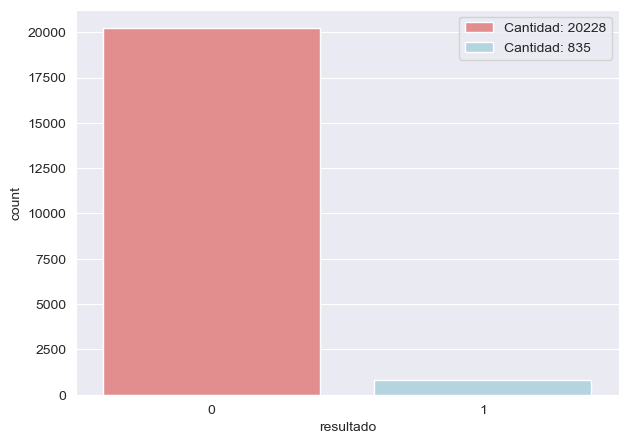

In [83]:
plt.figure(figsize=(7,5))
sns.countplot(data=dataset, x='resultado', palette=['lightcoral', 'lightblue'], 
              )
sns.set_style('darkgrid')
plt.legend([f'Cantidad: {dataset['resultado'].value_counts()[0]}', 
            f'Cantidad: {dataset['resultado'].value_counts()[1]}'])
plt.show()

## **Continuous Variables Analysis (Boxplots)**

Continuous variables were analyzed using boxplots to identify outliers.

Significant outliers were detected in variables such as spending and payment capacity, which were likely due to measurement errors. These values were removed to prevent distortions in model training.

Afterward, the variable distributions were reassessed, showing improved behavior after cleaning.

C:\Users\osqui\AppData\Local\Temp\ipykernel_25844\1397085228.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


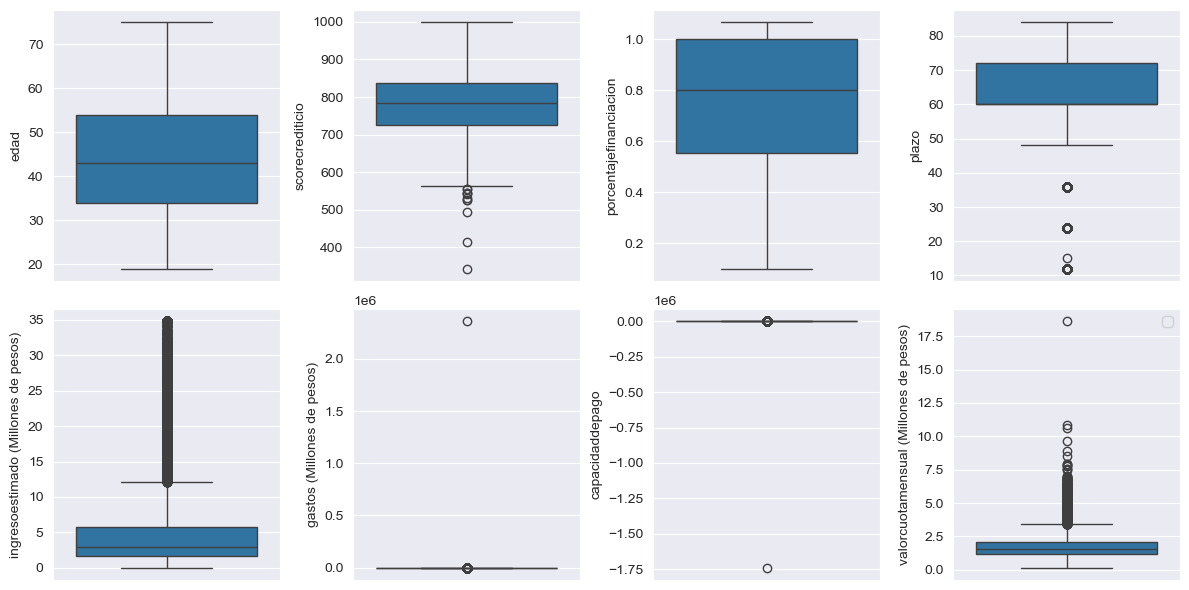

In [84]:
col_continuas = ['edad', 'scorecrediticio', 'porcentajefinanciacion', 'plazo', 'ingresoestimado', 
                 'gastos', 'capacidaddepago','valorcuotamensual']
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
for i, col in enumerate(col_continuas):
    ax = axs[i//4, i%4]
    sns.boxplot(dataset[col], ax=ax)
    if col in ['ingresoestimado', 'gastos', 'valorcuotamensual'] : 
        ax.set_ylabel(f'{col} (Millones de pesos)')
    
plt.legend()
plt.tight_layout()
sns.set_style('darkgrid')

In [85]:
#Tramamos el outlier por error de medición en gastos y capacidad de pago
dataset = dataset[(dataset['gastos'] != dataset['gastos'].max()) & (dataset['capacidaddepago'] != dataset['capacidaddepago'].min())]

## **Boxplot and Violin Plot Analysis (Without Outliers)**

Boxplots and violin plots were used to analyze the distribution of continuous variables after removing outliers.

This visualization allowed for a better understanding of the data distribution, density, and variability without the influence of extreme values. It also facilitated the identification of patterns and differences in the variables.

The results confirmed that the data cleaning process improved the interpretability and consistency of the variables.

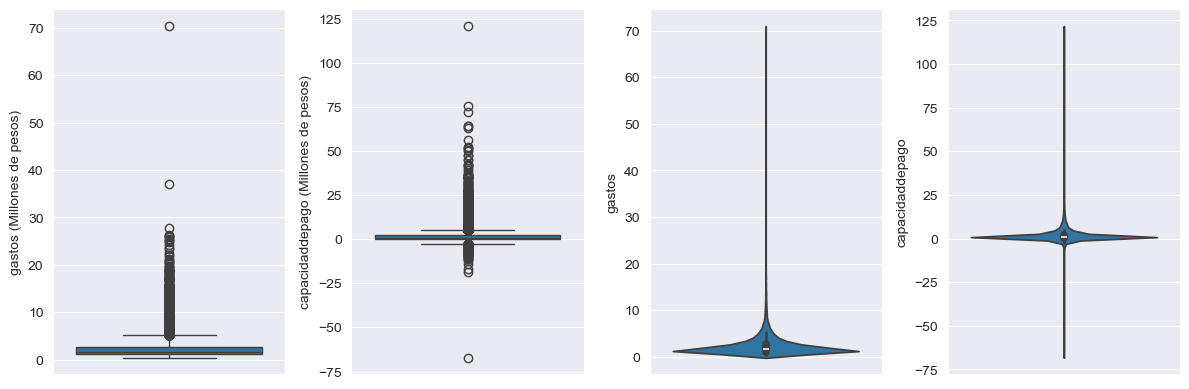

In [86]:
col = ['gastos', 'capacidaddepago']
fig, axs = plt.subplots(1, 4, figsize=(12, 4))
for i, col in enumerate(col):
    ax = axs[i]
    sns.boxplot(dataset[col], ax=ax)
    ax.set_ylabel(f'{col} (Millones de pesos)')

    sns.violinplot(dataset[col], ax=axs[i+2])

plt.tight_layout()
sns.set_style('darkgrid')

## **Histogram Analysis of Continuous Variables**

Histograms were used to analyze the distribution of continuous variables after outlier removal.

Most variables exhibit asymmetric (right-skewed) distributions, particularly financial variables such as estimated income, expenses, payment capacity, and monthly installment value, indicating that a large proportion of customers have low to moderate values, with fewer cases at higher levels.

The credit score shows a more symmetric, approximately normal distribution, suggesting a more balanced spread of values. In contrast, variables such as financing percentage and loan term present concentrated peaks, indicating common standard values used in credit allocation.

Overall, the distributions highlight the presence of skewness and concentration patterns, which are important to consider during model training and may justify the use of scaling or transformation techniques.

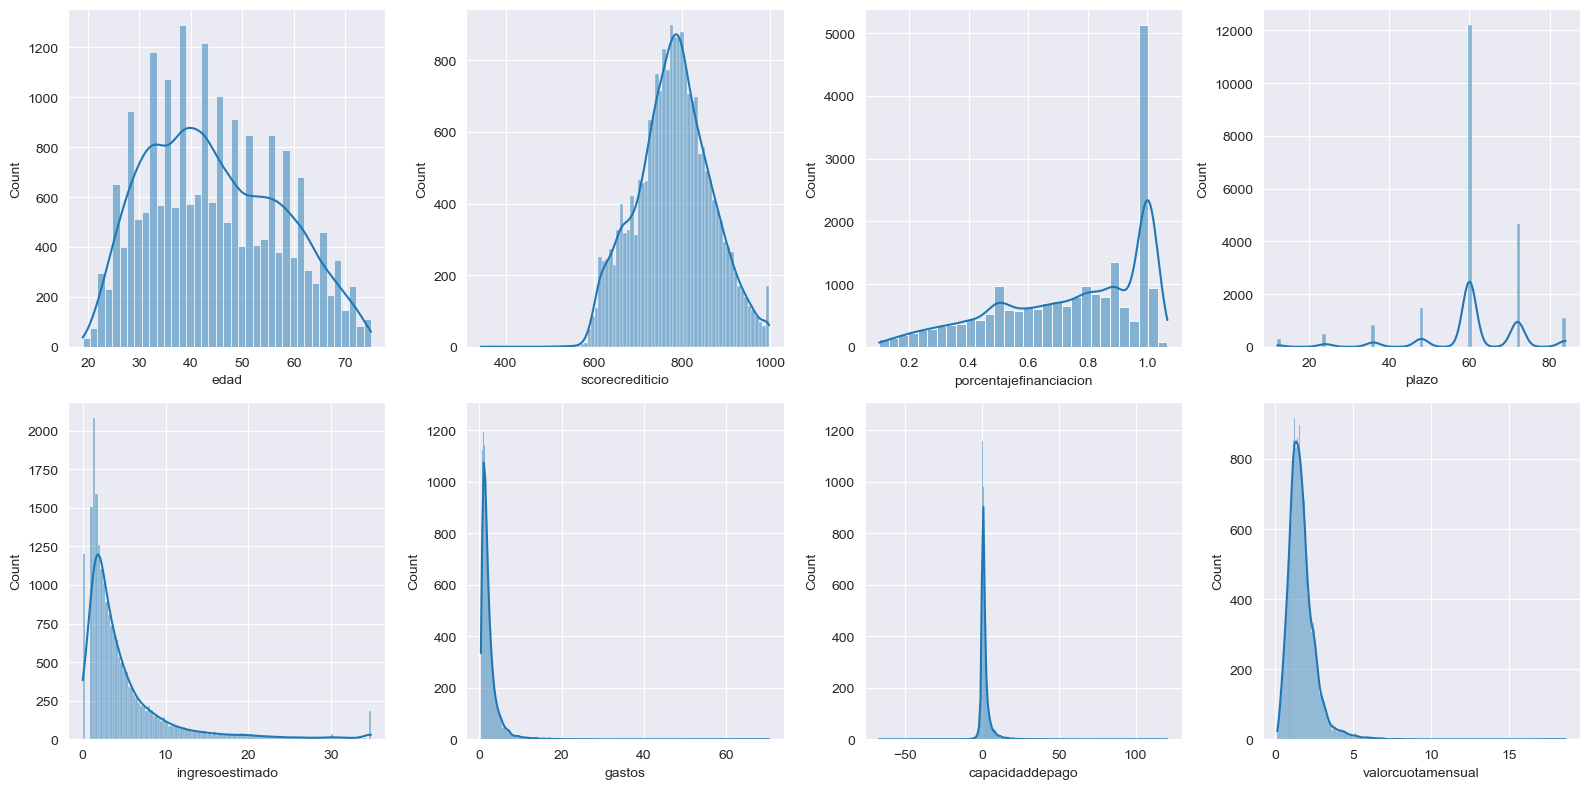

In [87]:
col_continuas = ['edad', 'scorecrediticio', 'porcentajefinanciacion', 'plazo', 'ingresoestimado', 
                 'gastos', 'capacidaddepago','valorcuotamensual']
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(col_continuas):
    ax = axs[i//4, i%4]
    sns.histplot(dataset[col], ax=ax, kde= True)
plt.tight_layout()
sns.set_style('darkgrid')

## **Discrete Variables Analysis**

Discrete variables were analyzed by comparing the proportion of approved and rejected loans across their categories.

The results showed no clear separation between classes, as the distribution of approvals and rejections is similar across categories such as `perfil`, `estado`, and `genero`.

This suggests that these variables, on their own, have limited discriminative power. However, they may still contribute to the model when combined with other variables.

Conclusión: si el credito se aprueba, hay un ligera preferencia por Asalariados, Hombres y vehiculos nuevos

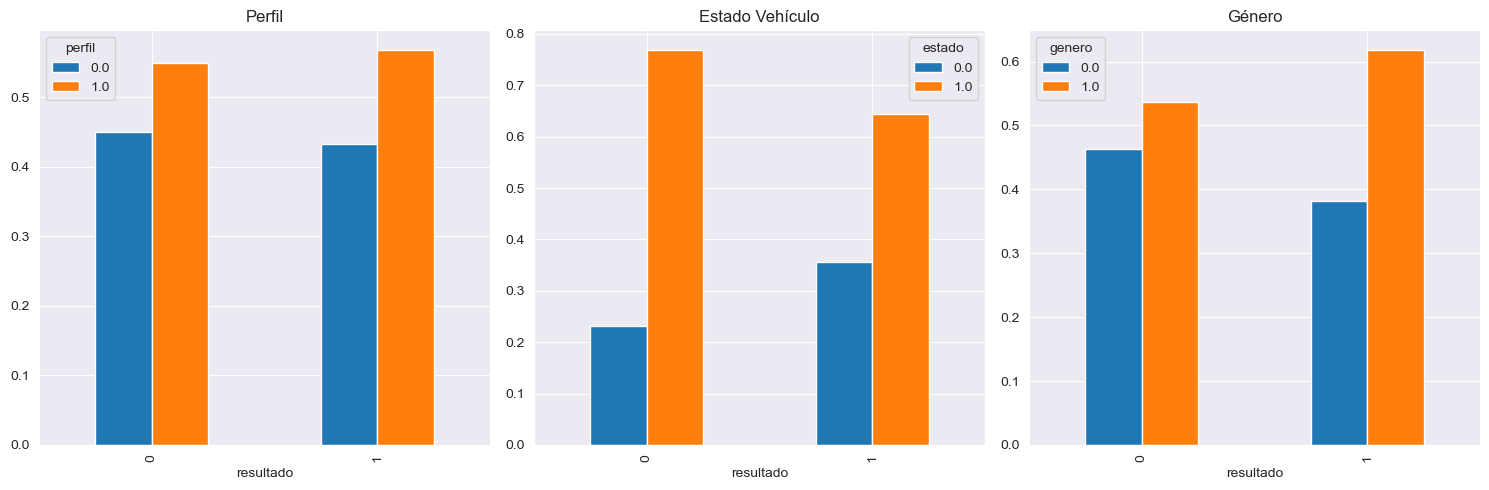

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Perfil (0=Independiente, 1=Asalariado)
pd.crosstab(dataset['resultado'], dataset['perfil'], normalize='index') \
    .plot(kind='bar', ax=axes[0], title='Perfil')

# Estado del vehículo (0=Usado, 1=Nuevo)
pd.crosstab(dataset['resultado'], dataset['estado'], normalize='index') \
    .plot(kind='bar', ax=axes[1], title='Estado Vehículo')

# Género (0=Femenino, 1=Masculino)
pd.crosstab(dataset['resultado'], dataset['genero'], normalize='index') \
    .plot(kind='bar', ax=axes[2], title='Género')

sns.set_style('darkgrid')
plt.tight_layout()
plt.show()

## **Correlation Analysis**

The correlation analysis showed no strong relationships between most features. A moderate correlation was observed between estimated income and payment capacity; however, it was not considered significant.

Additionally, none of the features exhibited a high correlation with the target variable, indicating limited individual predictive power and suggesting that model performance relies on the combined effect of multiple variables.

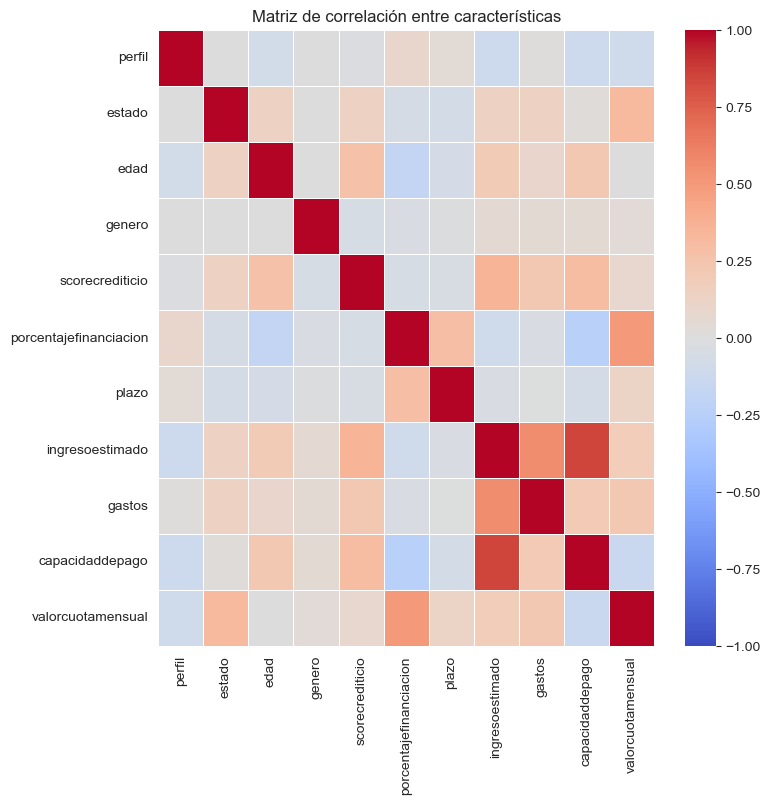

In [89]:
corr_matrix = dataset.drop(columns=['resultado']).corr(method='spearman')
plt.figure(figsize=(8,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, fmt='.2f', linewidths=0.5, vmin= -1, vmax= 1)
plt.title('Matriz de correlación entre características')
plt.show()

In [90]:
results = dict()
for column in dataset.drop(columns=['resultado']).columns:
    coef, p_val = pointbiserialr(dataset[column], dataset['resultado'])
    results[column] = {'Correlation': coef, 'P_value': p_val}
results_df = pd.DataFrame(results).T.sort_values(by= 'Correlation', ascending= False)
results_df

,Correlation,P_value
porcentajefinanciacion,0.135958,1.918036e-87
valorcuotamensual,0.082620,3.135770e-33
plazo,0.050465,2.333256e-13
genero,0.031620,4.435744e-06
perfil,0.007158,2.988902e-01
gastos,-0.014201,3.931339e-02
ingresoestimado,-0.047308,6.461526e-12
edad,-0.050130,3.353845e-13
capacidaddepago,-0.055768,5.528099e-16
estado,-0.056967,1.298796e-16


## **Data Splitting and Sampling**

The dataset was divided into training and test sets to evaluate model performance under realistic conditions.

Given the strong class imbalance, random undersampling without replacement was applied only to the training set, achieving an approximate 60-40 class distribution.

Models were trained using both the original (imbalanced) dataset and the balanced dataset in order to compare their performance under different data conditions.

The test set was kept unchanged to preserve the original distribution and ensure an unbiased evaluation of the model.

In [91]:
X = dataset.drop(columns=['resultado'])
y = dataset['resultado']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

C:\Users\osqui\AppData\Local\Temp\ipykernel_25844\1575754465.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette=['lightcoral', 'lightblue'])
C:\Users\osqui\AppData\Local\Temp\ipykernel_25844\1575754465.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_bal, ax=axes[1], palette=['lightcoral', 'lightblue'])


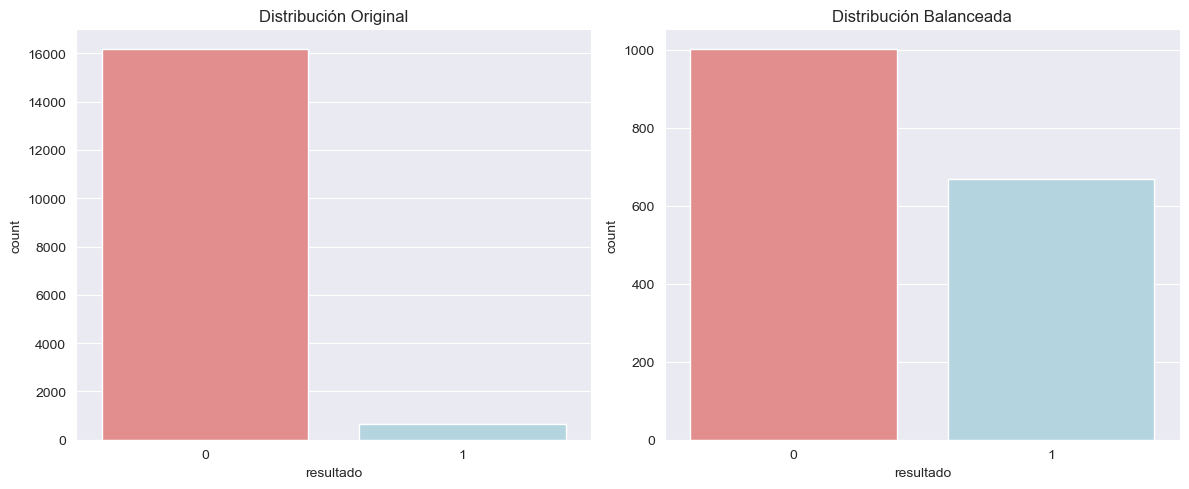

In [92]:
#Unimos el conjunto de train 
train = pd.concat([X_train, y_train], axis= 1)

#Separamos las clases
mayoritaria = train[train['resultado'] == 0]
minoritaria = train[train['resultado'] == 1]

#Hacemos el muestreo aleatorio sin remplazo
mayoritaria_sample = resample(
                            mayoritaria, 
                            replace = False,
                            n_samples=(int(len(minoritaria)*1.5)), #60-40 aproximadamente
                            random_state= 42
)

#Creamos X_train y Y_train balanceados
train_balanceado = pd.concat([mayoritaria_sample, minoritaria])
X_train_bal = train_balanceado.drop(columns=['resultado'])
y_train_bal = train_balanceado['resultado']

#Creamos una grafica para comparar la distribución de la variable objetivo antes y después del balanceo
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x=y_train, ax=axes[0], palette=['lightcoral', 'lightblue'])
axes[0].set_title('Distribución Original')
sns.countplot(x=y_train_bal, ax=axes[1], palette=['lightcoral', 'lightblue'])
axes[1].set_title('Distribución Balanceada')
sns.set_style('darkgrid')
plt.tight_layout()
plt.show()

In [93]:
# Guardar datasets
X_train.to_pickle("../Data/processed/X_train.pkl")
X_train_bal.to_pickle("../Data/processed/X_train_bal.pkl")
X_test.to_pickle("../Data/processed/X_test.pkl")

y_train.to_pickle("../Data/processed/y_train.pkl")
y_train_bal.to_pickle("../Data/processed/y_train_bal.pkl")
y_test.to_pickle("../Data/processed/y_test.pkl")